# ***EXERCISE 1: Medical Insurance Cost Prediction***
* **Goal**: Predict individual medical insurance charges using regression models.
* **Dataset**: insurance.csv (1,338 rows, 7 columns).
* **Models**: Linear Regression (Baseline) + Random Forest Regressor (Advanced).

# ***1. Importing Libraries***

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ***2. Loading and Exploring the Dataset***

* *Reads the dataset from a CSV file using pd.read_csv().*
* *Displays dataset content to verify successful loading*
* *Confirms that the dataset contains the expected number of rows and columns.*

In [2]:
#Load Dataset
data = pd.read_csv("/kaggle/input/insurance/medical_insurance.csv")
print(data)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
2767   47  female  45.320         1     no  southeast   8569.86180
2768   21  female  34.600         0     no  southwest   2020.17700
2769   19    male  26.030         1    yes  northwest  16450.89470
2770   23    male  18.715         0     no  northwest  21595.38229
2771   54    male  31.600         0     no  southwest   9850.43200

[2772 rows x 7 columns]


# ***2.1 - Checking the Top Few Records***

* *Helps to understand the column names, data types, and general structure.*
* *Quick check for missing or unusual data patterns.*

In [3]:
#Display the first few rows to understand the dataset structure
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# ***2.2 - Checking the last Few Records***

In [4]:
#Display the last few rows for consistency check
print(data.tail())

      age     sex     bmi  children smoker     region      charges
2767   47  female  45.320         1     no  southeast   8569.86180
2768   21  female  34.600         0     no  southwest   2020.17700
2769   19    male  26.030         1    yes  northwest  16450.89470
2770   23    male  18.715         0     no  northwest  21595.38229
2771   54    male  31.600         0     no  southwest   9850.43200


# ***2.3 - Describing The Data***

* *Provides statistical summary for numeric columns (mean, min, max, etc.).*
* *Helps identify outliers and data spread.*

In [5]:
print(data.describe())

               age          bmi     children       charges
count  2772.000000  2772.000000  2772.000000   2772.000000
mean     39.109668    30.701349     1.101732  13261.369959
std      14.081459     6.129449     1.214806  12151.768945
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.220000     0.000000   4687.797000
50%      39.000000    30.447500     1.000000   9333.014350
75%      51.000000    34.770000     2.000000  16577.779500
max      64.000000    53.130000     5.000000  63770.428010


# ***3 - Exploratory Data Analysis (EDA)***

* *Visualizes how smoking habits impact medical costs.*
* *Uses a boxplot to compare “smoker” vs “non-smoker” charge distribution.*

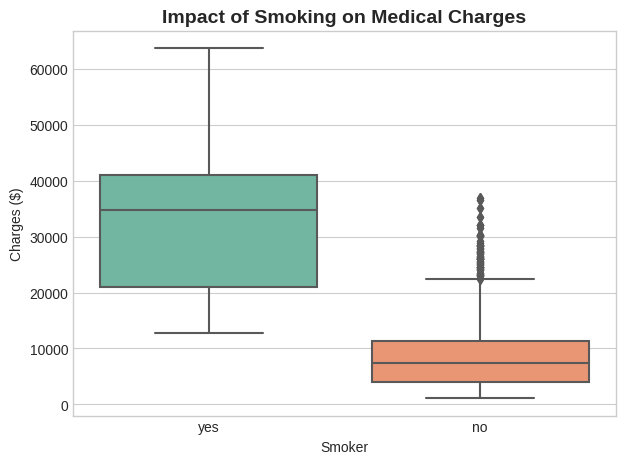

In [6]:
# Boxplot: Show how smoking impacts medical charges
plt.figure(figsize=(7,5))
sns.boxplot(x='smoker', y='charges', data=data, palette='Set2')
plt.title("Impact of Smoking on Medical Charges", fontsize=14, weight='bold')
plt.xlabel("Smoker")
plt.ylabel("Charges ($)")
plt.show()


* Insight: Smokers have significantly higher medical charges than non-smokers.*

# ***3.1 - distribution of medical insurance charges***

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


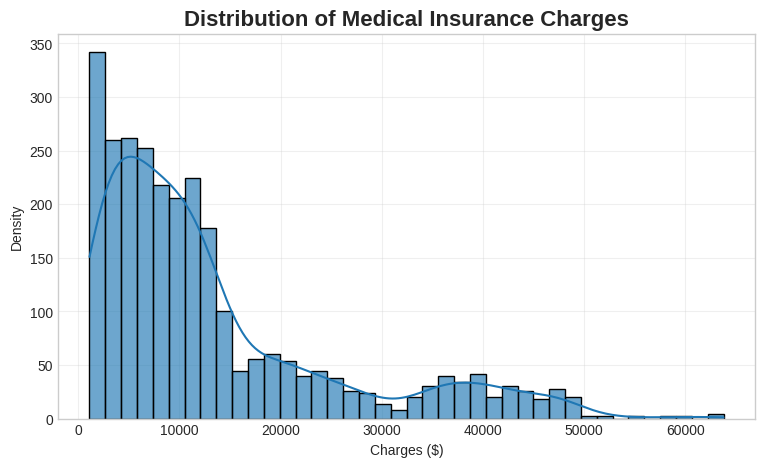

In [7]:
plt.figure(figsize=(9,5))

sns.histplot(
    data['charges'],
    bins=40,
    kde=True,
    color='#1f77b4',
    alpha=0.65,
    edgecolor='black'
)

plt.title("Distribution of Medical Insurance Charges", fontsize=16, weight='bold')
plt.xlabel("Charges ($)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()


* Insight: The charges are right-skewed, meaning most people pay less, but a few pay very high amounts.*

# ***4. Data Preprocessing***

* *Removes unnecessary columns (like ‘region’) to reduce noise.*
* *Simplifies the model by focusing on key predictive variables.*
* *Prepares clean region for training.*

In [8]:
# Drop the 'region' column 
data = data.drop("region", axis=1)
data.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


# 4.1 Feature Engineering

In [9]:
# BMI Category Feature
def bmi_category(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "healthy"
    elif bmi < 30:
        return "overweight"
    else:
        return "obese"

data["bmi_category"] = data["bmi"].apply(bmi_category)

# Interaction Features
data["age_bmi_interaction"] = data["age"] * data["bmi"]
data["smoker_bmi_interaction"] = data["bmi"] * data["smoker"].map({"yes": 1, "no": 0})

# Polynomial Feature (BMI^2)
data["bmi_squared"] = data["bmi"] ** 2

print(data[["bmi", "bmi_category", "age_bmi_interaction", "smoker_bmi_interaction", "bmi_squared"]].head())


      bmi bmi_category  age_bmi_interaction  smoker_bmi_interaction  \
0  27.900   overweight              530.100                    27.9   
1  33.770        obese              607.860                     0.0   
2  33.000        obese              924.000                     0.0   
3  22.705      healthy              749.265                     0.0   
4  28.880   overweight              924.160                     0.0   

   bmi_squared  
0   778.410000  
1  1140.412900  
2  1089.000000  
3   515.517025  
4   834.054400  


# ***5. Feature and Target Selection***

* *Separates the dataset into:*
  * X → input features (independent variables).
  * Y → target column “charges” (dependent variable).

In [10]:
# Separate input features (X) and target variable (Y)
X = data.drop(["charges"], axis=1)
Y = data["charges"]

# ***6. Encoding Categorical Variables***

* *Converts text labels (like “yes”, “no”, “male”, “female”) into numeric form.*
* *Uses get_dummies() with drop_first=True to prevent multicollinearity.*

In [11]:
# Convert categorical variables into numerical form using one-hot encoding
X = data.drop(["charges"], axis=1)
X = pd.get_dummies(X, drop_first=True)
Y = data["charges"]

# ***7. Splitting the Dataset***

* *Divides data into training (80%) and testing (20%) portions.*
* *Ensures the model learns from one part and is tested on unseen data.*

In [12]:
#Split data into training (80%) and testing (20%) sets for fair evaluation

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=42)

# ***8. Model Training – Linear Regression***

* *Creates a Linear Regression model object.*
* *Fits (trains) the model using training data (X_train, Y_train).*

In [13]:
# Train the Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

LinearRegression()

# ***9. Making Predictions***

* *Uses the trained model to predict medical charges on unseen data (X_test).*
* *Produces predicted results stored in Y_predict.*
* *These predictions will be compared with real test data.*

In [14]:
# Predict medical charges on the test set
lr_pred = lr_model.predict(X_test)

# ***10. Model Evaluation***

* *Calculates key performance metrics:*
 * *MAE → average absolute difference between predictions and true values.*
 * *MSE → penalizes larger errors more heavily.*
 * *R² Score → shows how well the model explains variance in data.*

In [15]:
# Evaluate model using key regression metrics
lr_mae = mean_absolute_error(Y_test, lr_pred)
lr_mse = mean_squared_error(Y_test, lr_pred)
lr_r2 = r2_score(Y_test, lr_pred)

print("Linear Regression:")
print(" MAE:", round(lr_mae, 3))
print(" MSE:", round(lr_mse, 3))
print(" R² :", round(lr_r2, 3))

Linear Regression:
 MAE: 2927.173
 MSE: 25486285.287
 R² : 0.834


# ***11. Actual vs Predicted Visualization***

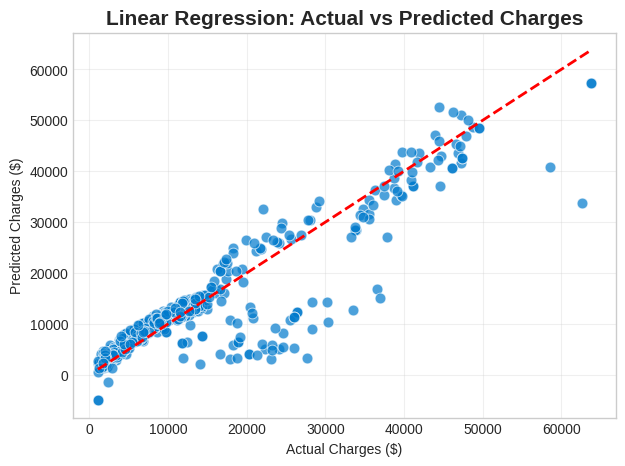

In [16]:
#Scatter plot to compare actual vs predicted charges
plt.figure(figsize=(7,5))
sns.scatterplot(x=Y_test, y=lr_pred, alpha=0.7, s=60, color='#007acc')

# 45-degree perfect line
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    '--r', linewidth=2
)

plt.title("Linear Regression: Actual vs Predicted Charges", fontsize=15, weight='bold')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.grid(alpha=0.3)
plt.show()


* Insight: Points close to the diagonal indicate good prediction accuracy.*

# ***12. Residuals Distribution (Error Analysis)***

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


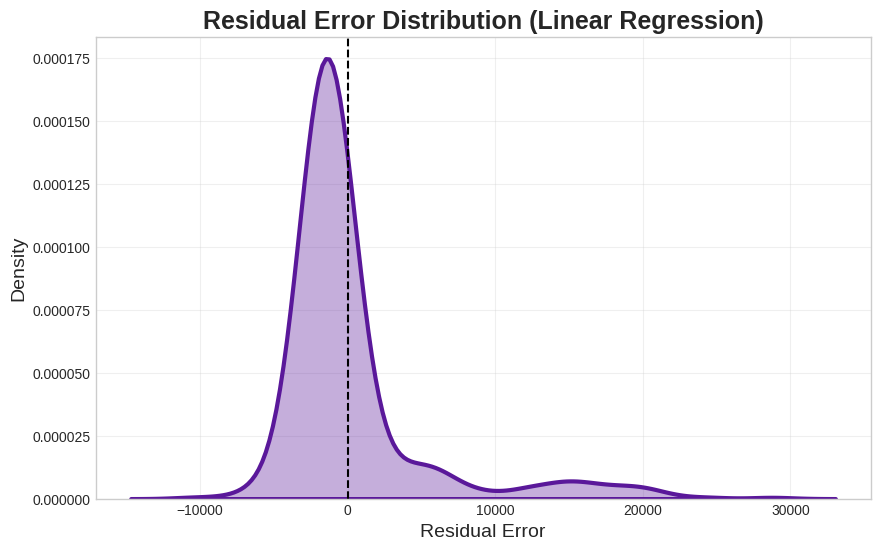

In [17]:
# Professional Residuals Distribution Plot

residuals = Y_test - lr_pred

plt.figure(figsize=(10,6))
sns.kdeplot(residuals, fill=True, color='#5A189A', alpha=0.35, linewidth=3)

plt.axvline(0, color='black', linestyle='--', linewidth=1.5)

plt.title("Residual Error Distribution (Linear Regression)", fontsize=18, weight='bold')
plt.xlabel("Residual Error", fontsize=14)
plt.ylabel("Density", fontsize=14)

plt.grid(alpha=0.3)
plt.show()


 Insight: The errors are mostly centered around zero, showing balanced predictions.

# ***13. Feature Importance (Coefficient Analysis)***

* *Extracts and ranks coefficients from the trained model.*
* *Positive coefficients = increase in charges; negative = decrease.*

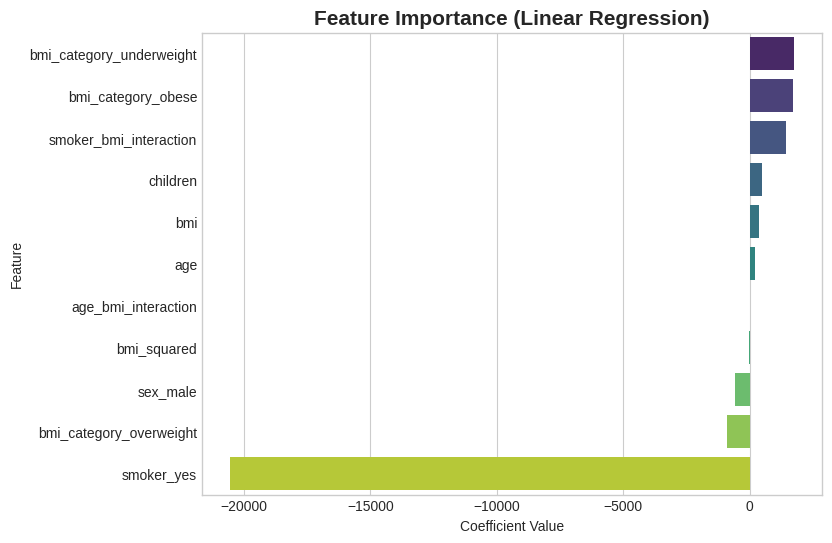

,Feature,Coefficient
10,bmi_category_underweight,1747.694681
8,bmi_category_obese,1726.264102
4,smoker_bmi_interaction,1446.180077
2,children,472.948825
1,bmi,365.399324


In [18]:
#Identifies which features have the strongest impact on predicted charges.
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=coeff_df, x='Coefficient', y='Feature', palette='viridis')
plt.title("Feature Importance (Linear Regression)", fontsize=15, weight='bold')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

coeff_df.head()



# 13.1 Hyperparameter Tuning

In [19]:
from sklearn.model_selection import GridSearchCV

# Random Forest Parameter Grid
rf_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train, Y_train)

print("Best RF Params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

Best RF Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


# **14 - Advanced Model 1: Random Forest Regressor**

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2
)

rf_model.fit(X_train, Y_train)
rf_pred = rf_model.predict(X_test)

# Random Forest Regressor — Model Performance Metrics

In [21]:
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_r2 = r2_score(Y_test, rf_pred)

print("Random Forest Regressor:")
print(" MAE:", round(rf_mae, 3))
print(" MSE:", round(rf_mse, 3))
print(" R² :", round(rf_r2, 3))

Random Forest Regressor:
 MAE: 1387.211
 MSE: 8741775.661
 R² : 0.943


# **14. 1 - Advanced Model 2: Gradient Boosting Regressor**

In [22]:
gb_params = {
    "n_estimators": [150, 200, 300],"learning_rate": [0.03, 0.05, 0.1],"max_depth": [2, 3, 4]}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=0
)

gb_grid.fit(X_train, Y_train)

print("Best GB Params:", gb_grid.best_params_)
best_gb = gb_grid.best_estimator_
gb_pred = best_gb.predict(X_test)

Best GB Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}


# Boosting Regressor - Model Performance

In [23]:
gb_mae = mean_absolute_error(Y_test, gb_pred)
gb_mse = mean_squared_error(Y_test, gb_pred)
gb_r2 = r2_score(Y_test, gb_pred)

print("Gradient Boosting Regressor:")
print(" MAE:", round(gb_mae, 3))
print(" MSE:", round(gb_mse, 3))
print(" R² :", round(gb_r2, 3))

Gradient Boosting Regressor:
 MAE: 1505.742
 MSE: 9809951.121
 R² : 0.936


# **15. - Model Performance Comparison Table**

In [24]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_mae, rf_mae, gb_mae],
    "MSE": [lr_mse, rf_mse, gb_mse],
    "R2 Score": [lr_r2, rf_r2, gb_r2]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,R2 Score
1,Random Forest,1387.210539,8.741776e+06,0.943043
2,Gradient Boosting,1505.741767,9.809951e+06,0.936084
0,Linear Regression,2927.172668,2.548629e+07,0.833945


# 16 - Advanced Visualization: Combined Actual vs Predicted

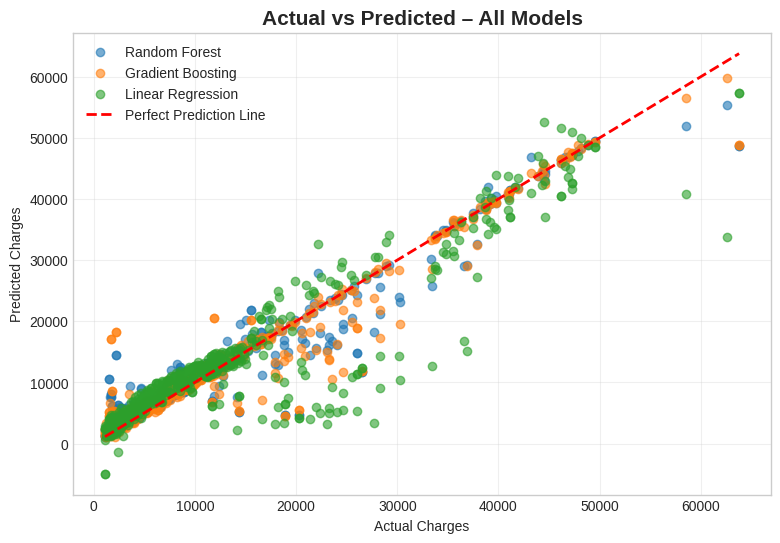

In [25]:
plt.figure(figsize=(9,6))
plt.scatter(Y_test, rf_pred, alpha=0.6, label="Random Forest")
plt.scatter(Y_test, gb_pred, alpha=0.6, label="Gradient Boosting")
plt.scatter(Y_test, lr_pred, alpha=0.6, label="Linear Regression")

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    'r--', linewidth=2, label="Perfect Prediction Line"
)

plt.title("Actual vs Predicted – All Models", fontsize=15, weight="bold")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 17 - Residual Analysis – All Models

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


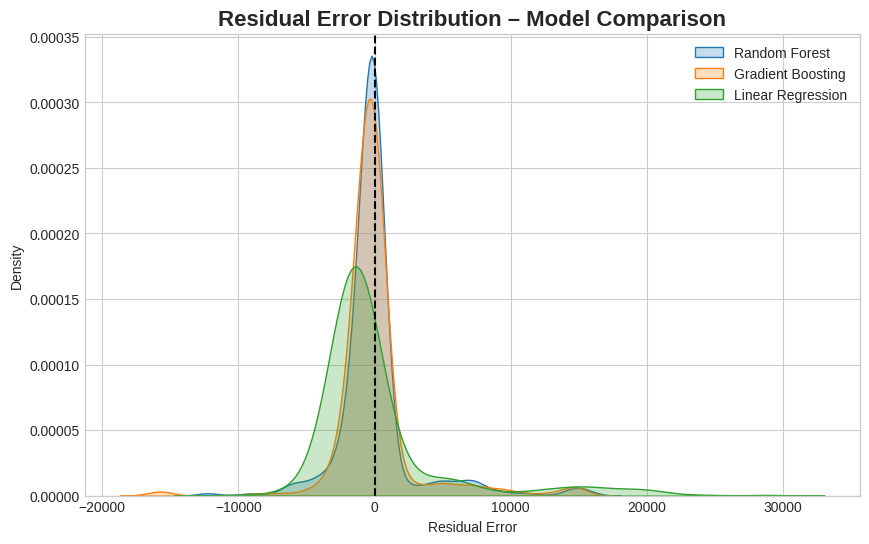

In [26]:
res_rf = Y_test - rf_pred
res_gb = Y_test - gb_pred
res_lr = Y_test - lr_pred

plt.figure(figsize=(10,6))
sns.kdeplot(res_rf, fill=True, label="Random Forest")
sns.kdeplot(res_gb, fill=True, label="Gradient Boosting")
sns.kdeplot(res_lr, fill=True, label="Linear Regression")

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Error Distribution – Model Comparison", fontsize=16, weight="bold")
plt.xlabel("Residual Error")
plt.ylabel("Density")
plt.legend()
plt.show()


# ***18 - Random Forest Feature Importance***

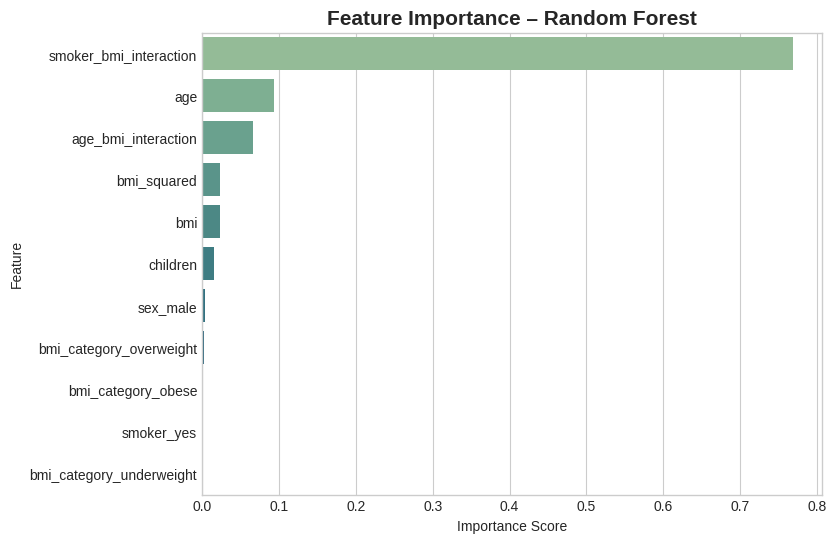

In [27]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='crest')
plt.title("Feature Importance – Random Forest", fontsize=15, weight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# ***19 - Final Accuracy***

In [28]:
print("Final Best Model (based on R²):")
print(results.sort_values(by="R2 Score", ascending=False).iloc[0])

Final Best Model (based on R²):
Model       Random Forest
MAE           1387.210539
MSE          8741775.6608
R2 Score         0.943043
Name: 1, dtype: object


# *20 - Final Summary*

In [29]:
summary = results.sort_values(by="R2 Score", ascending=False)
print("\nModel Performance Summary:")
print(summary)


Model Performance Summary:
               Model          MAE           MSE  R2 Score
1      Random Forest  1387.210539  8.741776e+06  0.943043
2  Gradient Boosting  1505.741767  9.809951e+06  0.936084
0  Linear Regression  2927.172668  2.548629e+07  0.833945


#  *----X--X---THE END---X---X----*

In [30]:
print("\n End of Notebook – Medical Insurance Cost Prediction Completed Successfully!")


 End of Notebook – Medical Insurance Cost Prediction Completed Successfully!
